In [1]:
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
from mpl_toolkits.mplot3d import Axes3D


from rdkit.Chem import rdMolAlign
import pandas as pd
import gudhi as gd
import glob

from matplotlib import cm

In [2]:
# Nombre del archivo SDF combinado
input_file = "geometrias.sdf"
output_file = "geometrias_SinE_with_IDs.sdf"

In [3]:
# Leer las moléculas del archivo SDF combinado
suppl = Chem.SDMolSupplier(input_file, removeHs=False)

In [4]:
# Verificar si los conformeros ya tienen ID y asignar si no lo tienen
molecules = []
writer = Chem.SDWriter(output_file)

for i, mol in enumerate(suppl):
    if mol is not None:
        # Verificar si el conformero tiene el campo 'ID'
        if not mol.HasProp('ID'):
            # Asignar un ID único en función del índice
            mol.SetProp('ID', f"Conf_{i+1}")
        
        # Agregar la molécula a la lista
        molecules.append(mol)
        # Escribir la molécula en el archivo de salida con el ID asignado
        writer.write(mol)

# Cerrar el archivo de salida
writer.close()
print(f"Archivo SDF reescrito con IDs asignados a cada conformero: {output_file}")

Archivo SDF reescrito con IDs asignados a cada conformero: geometrias_SinE_with_IDs.sdf


In [5]:
# Nombre del archivo SDF combinado con IDs
input_file = "geometrias_SinE_with_IDs.sdf"
output_file_with_energy = "geometrias_with_IDs_and_Energy.sdf"

In [6]:
# Leer las moléculas del archivo SDF combinado con IDs
suppl = Chem.SDMolSupplier(input_file, removeHs=False)

In [7]:
# Lista para almacenar las energías calculadas
energies = []

In [8]:
# Preparar el archivo SDF de salida para guardar los conformeros con la energía
writer = Chem.SDWriter(output_file_with_energy)

In [9]:
# Calcular la energía para cada conformero utilizando MMFF94s
for mol in suppl:
    if mol is not None:
        # Obtener el ID del conformero
        conformer_id = mol.GetProp("ID")
        
        # Configurar el campo de fuerza MMFF94s
        props = AllChem.MMFFGetMoleculeProperties(mol, mmffVariant='MMFF94s')
        if props is not None:
            # Crear el campo de fuerza para el conformero
            forcefield = AllChem.MMFFGetMoleculeForceField(mol, props)
            if forcefield is not None:
                # Optimizar la geometría y calcular la energía
                energy = forcefield.CalcEnergy()
                
                # Guardar la energía en la lista
                energies.append(energy)
                
                # Añadir la energía como una propiedad al conformero
                mol.SetProp("Energy_MMFF94s", f"{energy:.4f}")
                
                # Escribir el conformero con la energía en el archivo de salida
                writer.write(mol)
                print(f"Conformer {conformer_id}: Energy = {energy:.4f} kcal/mol")

Conformer Conf_1: Energy = -4.7240 kcal/mol
Conformer Conf_2: Energy = -4.7035 kcal/mol
Conformer Conf_3: Energy = -4.6297 kcal/mol
Conformer Conf_4: Energy = -4.5105 kcal/mol
Conformer Conf_5: Energy = -4.3468 kcal/mol
Conformer Conf_6: Energy = -4.1423 kcal/mol
Conformer Conf_7: Energy = -3.9080 kcal/mol
Conformer Conf_8: Energy = -3.6420 kcal/mol
Conformer Conf_9: Energy = -3.3531 kcal/mol
Conformer Conf_10: Energy = -3.0491 kcal/mol
Conformer Conf_11: Energy = -2.7368 kcal/mol
Conformer Conf_12: Energy = -2.4240 kcal/mol
Conformer Conf_13: Energy = -2.1180 kcal/mol
Conformer Conf_14: Energy = -1.8245 kcal/mol
Conformer Conf_15: Energy = -1.5551 kcal/mol
Conformer Conf_16: Energy = -1.3138 kcal/mol
Conformer Conf_17: Energy = -1.1075 kcal/mol
Conformer Conf_18: Energy = -0.9417 kcal/mol
Conformer Conf_19: Energy = -0.8209 kcal/mol
Conformer Conf_20: Energy = -0.7488 kcal/mol
Conformer Conf_21: Energy = -0.7278 kcal/mol
Conformer Conf_22: Energy = -0.7555 kcal/mol
Conformer Conf_23: 

In [10]:
# Cerrar el archivo SDF de salida
writer.close()
print(f"Energías calculadas y guardadas en '{output_file_with_energy}'.")

Energías calculadas y guardadas en 'geometrias_with_IDs_and_Energy.sdf'.


In [11]:
# Archivo de entrada con IDs y energías
input_file_with_energy = "geometrias_with_IDs_and_Energy.sdf"

In [12]:
# Leer las moléculas del archivo SDF combinado con IDs y energías
suppl = Chem.SDMolSupplier(input_file_with_energy, removeHs=False)

In [13]:
# Convertir las moléculas a una lista
molecules = [mol for mol in suppl if mol is not None]

In [14]:
# Número de conformeros
n_conformers = len(molecules)

In [15]:
# Crear una matriz para almacenar los valores de RMSD
rmsd_matrix = np.zeros((n_conformers, n_conformers))

In [16]:
# Listas para almacenar IDs y energías
conformer_ids = []
conformer_energies = []

In [ ]:
# Calcular la RMSD entre todos los pares de conformeros
for i in range(n_conformers):
    ref_conf = molecules[i].GetConformer()
    
    # Obtener la identificación del conformero y la energía
    conformer_id = molecules[i].GetProp("ID")
    conformer_energy = float(molecules[i].GetProp("Energy_MMFF94s"))
    
    conformer_ids.append(conformer_id)
    conformer_energies.append(conformer_energy)
    
    for j in range(i+1, n_conformers):
        prb_conf = molecules[j].GetConformer()
        rmsd = AllChem.GetBestRMS(molecules[i], molecules[j])
        rmsd_matrix[i, j] = rmsd
        rmsd_matrix[j, i] = rmsd

In [18]:
# Guardar la matriz de distancia en un archivo de texto, junto con las identificaciones de los conformeros
output_rmsd_file = "rmsd_matrix_with_ids_and_energy.txt"
with open(output_rmsd_file, "w") as f:
    f.write("\t" + "\t".join(conformer_ids) + "\n")
    for cid, row in zip(conformer_ids, rmsd_matrix):
        f.write(cid + "\t" + "\t".join(map(lambda x: f"{x:.4f}", row)) + "\n")

print(f"Matriz RMSD calculada y guardada en '{output_rmsd_file}'.")

Matriz RMSD calculada y guardada en 'rmsd_matrix_with_ids_and_energy.txt'.


In [19]:
# Configuración del MDS para reducir a 3D
mds = MDS(n_components=3, dissimilarity="precomputed", random_state=42)
reduced_coords = mds.fit_transform(rmsd_matrix)

In [20]:
# Guardar las coordenadas proyectadas junto con la identificación del conformero y la energía
output_reduced_file = "reduced_coordinates_with_ids_and_energy.txt"
with open(output_reduced_file, "w") as f:
    f.write("ID\tX\tY\tZ\tEnergy_MMFF94s\n")
    for cid, coord, energy in zip(conformer_ids, reduced_coords, conformer_energies):
        f.write(f"{cid}\t{coord[0]:.4f}\t{coord[1]:.4f}\t{coord[2]:.4f}\t{energy:.4f}\n")

print(f"Coordenadas reducidas y guardadas en '{output_reduced_file}'.")

Coordenadas reducidas y guardadas en 'reduced_coordinates_with_ids_and_energy.txt'.


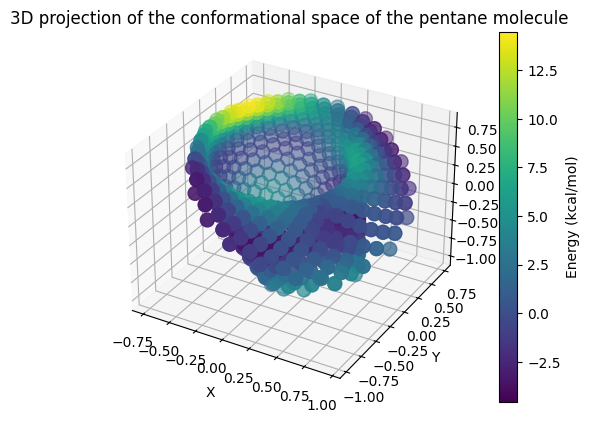

In [21]:
# Cargar las coordenadas 3D y energías desde el archivo
data = np.loadtxt("reduced_coordinates_with_ids_and_energy.txt", delimiter='\t', skiprows=1, usecols=(1, 2, 3, 4))

# Extraer las coordenadas X, Y, Z y las energías
x_coords = data[:, 0]
y_coords = data[:, 1]
z_coords = data[:, 2]
energies = data[:, 3]

# Normalizar las energías para el mapeo de colores
norm = plt.Normalize(energies.min(), energies.max())
colors = cm.viridis(norm(energies))  # Utilizando el mapa de colores 'viridis'

# Crear una gráfica 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Dibujar los puntos en 3D y asignarles colores según las energías
scatter = ax.scatter(x_coords, y_coords, z_coords, c=colors, marker='o', s=100)

# Etiquetas y ajustes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D projection of the conformational space of the pentane molecule')

# Añadir una barra de colores asociada a las energías
cbar = plt.colorbar(cm.ScalarMappable(norm=norm, cmap='viridis'), ax=ax)
cbar.set_label('Energy (kcal/mol)')

# Mostrar la gráfica
plt.show()

In [ ]:
#Homología persistente

In [22]:
# Cargar las coordenadas 3D desde el archivo
coords_data = np.loadtxt("reduced_coordinates_with_ids_and_energy.txt", delimiter='\t', skiprows=1, usecols=(1, 2, 3))

In [23]:
# Crear un complejo de Vietoris-Rips a partir de las coordenadas
rips_complex = gd.RipsComplex(points=coords_data, max_edge_length=0.50)

In [24]:
# Construir el complejo simplicial filtrado (Rips filtrado)
simplex_tree = rips_complex.create_simplex_tree(max_dimension=2)

In [25]:
# Calcular la homología persistente
persistence_diagram = simplex_tree.persistence()

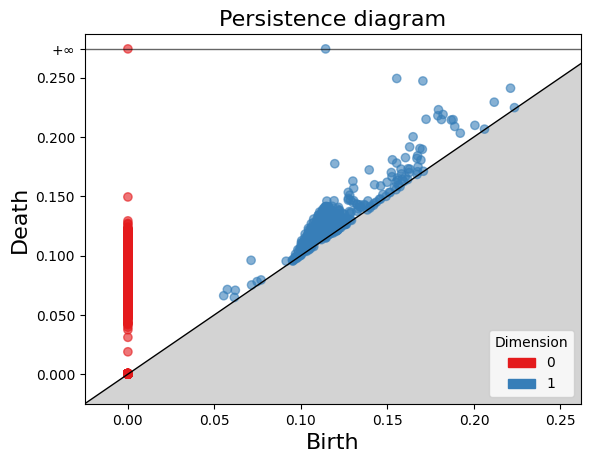

In [27]:
# Graficar el diagrama de persistencia
gd.plot_persistence_diagram(persistence_diagram)
plt.show()

In [ ]:
#Relativa vs Coordenada de Escaneo en kcal/mol

In [ ]:
# Leer el archivo de energía y escaneo 'bifenil_tot_ener.txt'
data = np.loadtxt("pentano_tot_ener.txt", skiprows=2)  # Saltamos las primeras dos filas de encabezado

In [28]:
# Extraer las columnas X y Y (coordenada de escaneo y energía total)
x_scan = data[:, 0]
y_energy = data[:, 1]

In [29]:
# Calcular la energía relativa tomando como referencia el valor mínimo
min_energy = np.min(y_energy)
y_relative_energy = y_energy - min_energy

In [30]:
# Convertir la energía relativa de Hartrees a kcal/mol
y_relative_energy_kcal = y_relative_energy * 630

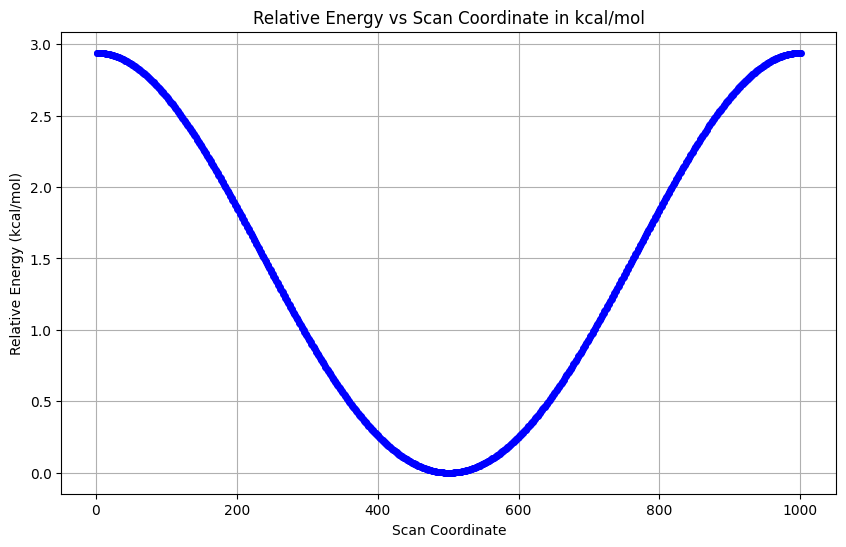

In [31]:
# Crear la gráfica de energía relativa en kcal/mol vs coordenada de escaneo
plt.figure(figsize=(10, 6))
plt.plot(x_scan, y_relative_energy_kcal, color='b', marker='o', linestyle='-', linewidth=1, markersize=4)
plt.xlabel("Scan Coordinate")
plt.ylabel("Relative Energy (kcal/mol)")
plt.title("Relative Energy vs Scan Coordinate in kcal/mol")
plt.grid(True)

# Guardar la gráfica como imagen
plt.savefig("energy_relative_vs_scan_kcal.png")
plt.show()

In [32]:
# Guardar el nuevo documento con la energía relativa en kcal/mol
output_data = np.column_stack((x_scan, y_relative_energy_kcal))
np.savetxt("bifenil_tot_ener_kcal.txt", output_data, fmt="%.6f", header="Coordenada_de_Escaneo\tEnergia_Relativa_kcal_mol")

print("Gráfica guardada como 'energy_relative_vs_scan_kcal.png' y datos guardados en 'bifenil_tot_ener_kcal.txt'.")

Gráfica guardada como 'energy_relative_vs_scan_kcal.png' y datos guardados en 'bifenil_tot_ener_kcal.txt'.
